# SPA613M Programming Assignment

You are part of an **IIT Kanpur** Celestial observing team studying **FRB 20220912A**, a repeating fast radio burst. This is one continuous assignment: it begins with units and time, moves through coordinate transformations and spherical calculations, develops the geometry and visibility of a source from GTC, and ends by answering progressively harder observing questions involving a FRB and a one-year all-sky GTC visibility infographic.

Use **UTC internally** for astronomical calculations. Whenever you report a civil clock time, show **IIT Kanpur time—Indian Standard Time (IST, `Asia/Kolkata`, UTC+05:30)** and retain UTC where requested.

**Total: 40 marks**  
**Optional:** Q20 carries 2 bonus marks.


## Marking Scheme

| Part | Questions | Topic | Marks |
|---|---:|---|---:|
| A | Q1–Q3 | Current time, quantities, conversions, JD/MJD, and IST | 5 |
| B | Q4–Q7 | Angles, coordinate systems, and angular separation | 8 |
| C | Q8–Q13 | GTC, LST, hour angle, transit, and altitude calculations | 12 |
| D | Q14–Q17 | Airmass, Sun, Moon, and practical visibility decisions | 9 |
| E | Q18 | Observing interval, GTC airmass figure, and interpretation | 4 |
| F | Q19 | Single-FRB visibility | 2 |
| Bonus extension | Q20 | One-year all-sky GTC animation | 2 bonus |
| **Assessed total** | **Q1–Q19** |  | **40** |


## Fixed target record

FRB 20220912A is a repeating fast radio burst. Use the following published VLBI position throughout the assignment:

- Source: `FRB 20220912A`
- ICRS/J2000 RA: `23h09m04.8989s`
- ICRS/J2000 Dec: `+48d42m23.9078s`
- Coordinate uncertainty: `5 mas`
- Dispersion measure: $219.46\,\mathrm{pc\,cm^{-3}}$
- Host redshift: $0.0771$

Source: Hewitt et al., *Milliarcsecond localization of the hyperactive repeating FRB 20220912A*, MNRAS 529, 1814–1830. The values above are frozen, so no catalogue or web query is required. [Published article](https://academic.oup.com/mnras/article/529/2/1814/7623035)

## Fixed GTC observing case

| Item | Course value |
|---|---|
| Observatory | Gran Telescopio Canarias (GTC) |
| Longitude | $-17.889^\circ$ |
| Latitude | $+28.758^\circ$ |
| Height | $2396\,\mathrm{m}$ |
| Calculation interval | `2026-08-30T12:00:00Z` through `2026-08-31T12:00:00Z` |
| Sampling | 10 minutes; both endpoints included; 145 samples |
| Minimum target altitude | $20^\circ$ |
| Permitted target airmass | finite $1\leq X\leq2.5$ |
| Astronomical darkness | Sun altitude $\leq-18^\circ$ |
| Minimum Moon separation | $30^\circ$ |

A target is observable only when **all four** target-altitude, target-airmass, Sun, and Moon-separation conditions pass simultaneously.

## Setup

Run the dependency cell before Q1. The setup supplies imports, fixed course constants, a reproducible offline astronomy configuration, an inclusive 145-sample UTC grid, IIT Kanpur formatting helpers, and a relative output directory.

In [73]:
import subprocess
import sys

REQUIRED_PACKAGES = [
    "numpy>=1.26",
    "matplotlib>=3.8",
    "astropy>=6.0",
    "astropy-iers-data",
    "tzdata",
    "healpy>=1.18",
    "astroplan>=0.10",
    "imageio>=2.31",
]

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--disable-pip-version-check",
        *REQUIRED_PACKAGES,
    ]
)
print("Dependencies installed: NumPy, Matplotlib, Astropy, IERS data, timezone data, healpy, astroplan, and imageio.")

Dependencies installed: NumPy, Matplotlib, Astropy, IERS data, timezone data, healpy, astroplan, and imageio.


In [74]:
from datetime import timezone
from pathlib import Path
from zoneinfo import ZoneInfo

import astropy
import matplotlib
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import healpy as hp
import numpy as np
from astropy import units as u
from astropy.coordinates import (
    AltAz,
    Angle,
    BarycentricTrueEcliptic,
    EarthLocation,
    SkyCoord,
    get_body,
    get_sun,
    solar_system_ephemeris,
)
from astropy.time import Time
from astropy.utils import iers
from astroplan import Observer

# Keep the astronomy calculation reproducible and independent of a live IERS download.
iers.conf.auto_download = False
iers.conf.auto_max_age = None

IITK_TIMEZONE = ZoneInfo("Asia/Kolkata")

FRB_NAME = "FRB 20220912A"
FRB_RA_J2000 = "23h09m04.8989s"
FRB_DEC_J2000 = "+48d42m23.9078s"
EARLIER_POSITION_RA = "23h09m04.9s"
EARLIER_POSITION_DEC = "+48d42m25.4s"

START_UTC = "2026-08-30T12:00:00"
STOP_UTC = "2026-08-31T12:00:00"
STEP_MINUTES = 10

GTC_LONGITUDE_DEG = -17.889
GTC_LATITUDE_DEG = 28.758
GTC_HEIGHT_M = 2396.0

MIN_TARGET_ALTITUDE_DEG = 20.0
MAX_AIRMASS = 2.5
MAX_SUN_ALTITUDE_DEG = -18.0
MIN_MOON_SEPARATION_DEG = 30.0

OUTPUT_DIR = Path("assignment_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# The inclusive 24-hour course grid is provided so you can focus on astronomy.
start_time = Time(START_UTC, scale="utc")
stop_time = Time(STOP_UTC, scale="utc")
step = STEP_MINUTES * u.min
number_of_steps = int(
    np.round(((stop_time - start_time) / step).to_value(u.dimensionless_unscaled))
)
times = start_time + np.arange(number_of_steps + 1) * step
assert len(times) == 145

def format_iitk(time_value):
    """Return one Astropy Time as the IIT Kanpur civil clock."""
    return time_value.to_datetime(timezone=IITK_TIMEZONE).strftime(
        "%Y-%m-%d %H:%M:%S IST"
    )

def format_utc(time_value):
    """Return one Astropy Time with an explicit UTC label."""
    return time_value.utc.strftime("%Y-%m-%d %H:%M:%S UTC")

print("Target:", FRB_NAME)
print("Observatory: Gran Telescopio Canarias (GTC)")
print("Course grid:", len(times), "samples")
print("IIT Kanpur civil timezone:", IITK_TIMEZONE)
print("Astronomical calculations use UTC; civil-time answers also show IST.")

Target: FRB 20220912A
Observatory: Gran Telescopio Canarias (GTC)
Course grid: 145 samples
IIT Kanpur civil timezone: Asia/Kolkata
Astronomical calculations use UTC; civil-time answers also show IST.


# Part A.  Astropy foundations: time, units, and conversions (5 marks)

## Q1. Current UTC and IIT Kanpur time [1 mark]

Call `Time.now()` exactly once and store it as `now`. Print that same instant as ISO UTC and as the IIT Kanpur civil clock with an `IST` label. In one sentence, explain why two separate calls to `Time.now()` need not describe exactly the same instant.

In [75]:
# YOUR ANSWER:
now = Time.now()

print("UTC:", now.utc.isot)
print("IIT Kanpur:", format_iitk(now))

# Write and run your code here. Add a Markdown cell below when an explanation is requested.


UTC: 2026-09-06T15:18:35.165
IIT Kanpur: 2026-09-06 20:48:35 IST


Two separate calls to `Time.now()` need not describe exactly the same instant because time continues to advance between the two calls.


## Q2. Physical quantities and unit conversions [2 marks]

Create Astropy quantities for the GTC height `2396 m`, wavelength `600 nm`, coordinate uncertainty `5 mas`, cadence `10 min`, and radio frequency `1.4 GHz`. Convert them respectively to kilometres, frequency in THz using `u.spectral()`, arcseconds, hours, and wavelength in centimetres using `u.spectral()`. Print every original value beside its converted value.

In [76]:
# YOUR ANSWER:
height = 2396 * u.m
wavelength = 600 * u.nm
uncertainty = 5 * u.mas
cadence = 10 * u.min
frequency = 1.4 * u.GHz

print("Height:", height, "=", height.to(u.km))
print("Wavelength:", wavelength, "=", wavelength.to(u.THz, equivalencies=u.spectral()))
print("Coordinate uncertainty:", uncertainty, "=", uncertainty.to(u.arcsec))
print("Cadence:", cadence, "=", cadence.to(u.hour))
print("Radio frequency:", frequency, "=", frequency.to(u.cm, equivalencies=u.spectral()))
# Write and run your code here. Add a Markdown cell below when an explanation is requested.

Height: 2396.0 m = 2.396 km
Wavelength: 600.0 nm = 499.6540966666666 THz
Coordinate uncertainty: 5.0 mas = 0.005 arcsec
Cadence: 10.0 min = 0.16666666666666666 h
Radio frequency: 1.4 GHz = 21.413747 cm


## Q3. UTC, JD, MJD, IST, and time arithmetic [2 marks]

Construct `planning_start = Time(START_UTC, scale="utc")`. Print UTC, Julian Date, Modified Julian Date, and IIT Kanpur time. Add `2.25 hour` with an Astropy quantity and print the later instant in UTC and IST. Finally verify that converting the original IST-aware Python datetime back into `Time` changes the instant by less than one microsecond.

In [77]:
# YOUR ANSWER:
planning_start = Time(START_UTC, scale="utc")

print("UTC:", planning_start.utc.isot)
print("Julian Date:", planning_start.jd)
print("Modified Julian Date:", planning_start.mjd)
print("IIT Kanpur:", format_iitk(planning_start))

later = planning_start + 2.25 * u.hour

print("\nAfter adding 2.25 hours:")
print("UTC:", later.utc.isot)
print("IIT Kanpur:", format_iitk(later))

# Convert the original IST-aware Python datetime back into Astropy Time
original_ist_datetime = planning_start.to_datetime(timezone=IITK_TIMEZONE)
round_trip = Time(original_ist_datetime)

difference = abs((round_trip - planning_start).to_value(u.microsecond))

print("\nRound-trip difference:", difference, "microseconds")
print("Less than 1 microsecond:", difference < 1)
# Write and run your code here. Add a Markdown cell below when an explanation is requested.

UTC: 2026-08-30T12:00:00.000
Julian Date: 2461283.0
Modified Julian Date: 61282.5
IIT Kanpur: 2026-08-30 17:30:00 IST

After adding 2.25 hours:
UTC: 2026-08-30T14:15:00.000
IIT Kanpur: 2026-08-30 19:45:00 IST

Round-trip difference: 0.0 microseconds
Less than 1 microsecond: True


# Part B. Angles and coordinate transformations (8 marks)


## Q4. Parse angles and construct an ICRS coordinate [2 marks]

Parse the target RA and Dec with `Angle`, then construct scalar `frb_icrs` with `SkyCoord`. Print RA and Dec in decimal degrees and padded sexagesimal notation. Verify RA $347.2704120833^\circ$ and Dec $+48.7066410556^\circ$ within $10^{-8}$ degree. Explain why RA commonly uses hours while Dec uses degrees.

In [78]:
# YOUR ANSWER:
ra = Angle(FRB_RA_J2000, unit=u.hourangle)
dec = Angle(FRB_DEC_J2000, unit=u.deg)

frb_icrs = SkyCoord(ra=ra, dec=dec, frame="icrs")

print("RA in decimal :", frb_icrs.ra.deg)
print("Dec in decimal :", frb_icrs.dec.deg)

print("RA in sexagesimal:", frb_icrs.ra.to_string(unit=u.hourangle, sep="hms", pad=True))
print("Dec in sexagesimal:", frb_icrs.dec.to_string(unit=u.deg, sep="dms", pad=True))

expected_ra = 347.2704120833
expected_dec = 48.7066410556

print("\nRA verification:", np.isclose(frb_icrs.ra.deg, expected_ra, atol=1e-8))
print("Dec verification:", np.isclose(frb_icrs.dec.deg, expected_dec, atol=1e-8))
# Write and run your code here. Add a Markdown cell below when an explanation is requested.

RA in decimal : 347.27041208333327
Dec in decimal : 48.70664105555556
RA in sexagesimal: 23h09m04.8989s
Dec in sexagesimal: 48d42m23.9078s

RA verification: True
Dec verification: True


Right Ascension is commonly expressed in hours because the celestial coordinate system is tied to Earth's rotation, with 24 hours corresponding to 360° around the celestial equator. Declination is measured as an angular distance north or south of the celestial equator, so it is naturally expressed in degrees.

## Q5. ICRS to Galactic and back [2 marks]

Transform `frb_icrs` to Galactic coordinates and print Galactic longitude $l$ and latitude $b$. Transform the result back to ICRS, calculate the round-trip separation in microarcseconds, and explain what a tiny non-zero residual represents.

In [79]:
# YOUR ANSWER:
frb_galactic = frb_icrs.galactic

print("Galactic longitude l:", frb_galactic.l.deg, "deg")
print("Galactic latitude b:", frb_galactic.b.deg, "deg")

frb_icrs_back = frb_galactic.icrs

separation = frb_icrs.separation(frb_icrs_back)

print("\nRound-trip separation:", separation.to(u.microarcsecond))
# Write and run your code here. Add a Markdown cell below when an explanation is requested.

Galactic longitude l: 106.06496077332801 deg
Galactic latitude b: -10.784176285402495 deg

Round-trip separation: 0.000289774 uarcsec


A tiny non-zero round-trip residual represents numerical round-off and finite floating-point precision in the coordinate transformations. It does not indicate a physical displacement of the source.

## Q6. ICRS to Ecliptic and back [2 marks]

Transform `frb_icrs` to barycentric true ecliptic coordinates at equinox J2000. Print ecliptic longitude $\lambda$ and latitude $\beta$ in degrees, verify their valid ranges, transform the result back to ICRS, and calculate the round-trip separation in microarcseconds. Explain what the ecliptic plane and the value of $\beta$ mean physically.

In [80]:
# YOUR ANSWER:
frb_ecliptic = frb_icrs.transform_to(
    BarycentricTrueEcliptic(equinox="J2000")
)

print("Ecliptic longitude lambda:", frb_ecliptic.lon.deg, "deg")
print("Ecliptic latitude beta:", frb_ecliptic.lat.deg, "deg")

print("\nLongitude valid:",
      0 <= frb_ecliptic.lon.deg < 360)

print("Latitude valid:",
      -90 <= frb_ecliptic.lat.deg <= 90)

frb_icrs_back = frb_ecliptic.transform_to("icrs")

separation = frb_icrs.separation(frb_icrs_back)

print("\nRound-trip separation:",
      separation.to(u.microarcsecond))
# Write and run your code here. Add a Markdown cell below when an explanation is requested.

Ecliptic longitude lambda: 14.411187650340095 deg
Ecliptic latitude beta: 48.34695843744783 deg

Longitude valid: True
Latitude valid: True

Round-trip separation: 0 uarcsec


The ecliptic plane is the plane of Earth's orbit around the Sun. Ecliptic latitude β measures how far a celestial object lies north or south of this plane. A value of β near zero means the object lies close to the ecliptic plane, while a larger absolute value means it is farther from the plane.


## Q7. Angular separation [2 marks]

Construct `earlier_position` from `23h09m04.9s`, `+48d42m25.4s`. Calculate the great-circle separation manually from

$$\cos(\Delta\theta)=\sin\delta_1\sin\delta_2+\cos\delta_1\cos\delta_2\cos(\alpha_2-\alpha_1).$$

Use radians inside NumPy, clip the computed cosine to $[-1,1]$, and report $\Delta\theta$ in arcseconds and milliarcseconds. Compare with `frb_icrs.separation(earlier_position)` and require agreement within $10^{-6}$ arcsecond.

In [81]:
# YOUR ANSWER:
earlier_position = SkyCoord(
    ra=Angle(EARLIER_POSITION_RA, unit=u.hourangle),
    dec=Angle(EARLIER_POSITION_DEC, unit=u.deg),
    frame="icrs"
)

# Converting coordinates to radians
ra1 = frb_icrs.ra.to_value(u.rad)
dec1 = frb_icrs.dec.to_value(u.rad)

ra2 = earlier_position.ra.to_value(u.rad)
dec2 = earlier_position.dec.to_value(u.rad)

# Great circle formula
cos_theta = (
    np.sin(dec1) * np.sin(dec2)
    + np.cos(dec1) * np.cos(dec2) * np.cos(ra2 - ra1)
)

# Protect against tiny floating-point excursions outside [-1, 1]
cos_theta = np.clip(cos_theta, -1.0, 1.0)

theta = np.arccos(cos_theta) * u.rad

print("Manual angular separation:")
print("Arcseconds:", theta.to_value(u.arcsec))
print("Milliarcseconds:", theta.to_value(u.mas))

# Astropy calculation
astropy_separation = frb_icrs.separation(earlier_position)

print("\nAstropy angular separation:")
print("Arcseconds:", astropy_separation.to_value(u.arcsec))
print("Milliarcseconds:", astropy_separation.to_value(u.mas))

difference = abs(
    theta.to_value(u.arcsec)
    - astropy_separation.to_value(u.arcsec)
)

print("\nDifference:", difference, "arcsec")
print("Agreement within 1e-6 arcsec:", difference < 1e-6)
# Write and run your code here. Add a Markdown cell below when an explanation is requested.

Manual angular separation:
Arcseconds: 1.4922374490540065
Milliarcseconds: 1492.2374490540062

Astropy angular separation:
Arcseconds: 1.492239726203449
Milliarcseconds: 1492.239726203449

Difference: 2.277149442564408e-06 arcsec
Agreement within 1e-6 arcsec: False


# Part C. GTC geometry, LST, transit, and altitude calculations (12 marks)

## Q8. Define the GTC observing site [1 mark]

Construct `gtc_location` with `EarthLocation.from_geodetic`, attaching units to the frozen longitude, latitude, and height. Print the recovered geodetic values. State what the negative longitude sign means.

In [82]:
# YOUR ANSWER:

gtc_location = EarthLocation.from_geodetic(
    lon=GTC_LONGITUDE_DEG * u.deg,
    lat=GTC_LATITUDE_DEG * u.deg,
    height=GTC_HEIGHT_M * u.m
)

lon, lat, height = gtc_location.to_geodetic()

print("GTC longitude:", lon)
print("GTC latitude:", lat)
print("GTC height:", height)
# Write and run your code here. Add a Markdown cell below when an explanation is requested.

GTC longitude: -17d53m20.4s
GTC latitude: 28d45m28.8s
GTC height: 2395.9999999997463 m


The negative longitude means that the GTC is located west of the Greenwich meridian

## Q9. Calculate GTC LST and hour angle at one instant [2 marks]

At `2026-08-31T00:00:00Z`, calculate apparent GTC Local Sidereal Time and target hour angle $H=\mathrm{LST}-\alpha$, wrapped at $\pm12$ hours. Print UTC, IIT Kanpur time, LST, and hour angle. From the sign of $H$, state whether the target is east of the meridian, transiting, or west of the meridian.

In [83]:
# YOUR ANSWER:

q9_time = Time("2026-08-31T00:00:00", scale="utc")

# Apparent local sidereal time at GTC
lst = q9_time.sidereal_time(
    kind="apparent",
    longitude=gtc_location.lon
)

# Hour angle H = LST - RA
hour_angle = (lst - frb_icrs.ra).wrap_at(12 * u.hourangle)

print("UTC:", q9_time.utc.isot)
print("IIT Kanpur:", format_iitk(q9_time))
print("GTC LST:", lst.to_string(unit=u.hourangle, sep="hms"))
print("Hour angle:", hour_angle.to_string(unit=u.hourangle, sep="hms"))
# Write and run your code here. Add a Markdown cell below when an explanation is requested.

UTC: 2026-08-31T00:00:00.000
IIT Kanpur: 2026-08-31 05:30:00 IST
GTC LST: 21h25m12.20694727s
Hour angle: -1h43m52.69195273s


A negative hour angle means the source is east of the meridian

## Q10. Find the nearest sampled meridian transit [2 marks]

Calculate apparent GTC LST and wrapped hour angle for all 145 samples. Locate the nearest sampled meridian transit by minimizing absolute hour angle. Print the sample index, UTC, IIT Kanpur time, LST, and hour angle. Explain why this is a sampled approximation rather than the exact transit instant.

In [84]:
# YOUR ANSWER:
# Q10: Find the nearest sampled meridian transit

lst_all = times.sidereal_time(
    kind="apparent",
    longitude=gtc_location.lon
)

hour_angles = (lst_all - frb_icrs.ra).wrap_at(12 * u.hourangle)

# Find the sample with the smallest absolute hour angle
transit_index = np.argmin(
    np.abs(hour_angles.to_value(u.hourangle))
)

transit_time = times[transit_index]
transit_lst = lst_all[transit_index]
transit_hour_angle = hour_angles[transit_index]

print("Sample index:", transit_index)
print("UTC:", format_utc(transit_time))
print("IIT Kanpur:", format_iitk(transit_time))
print("LST:", transit_lst.to_string(unit=u.hourangle, sep="hms"))
print("Hour angle:",
      transit_hour_angle.to_string(unit=u.hourangle, sep="hms"))
# Write and run your code here. Add a Markdown cell below when an explanation is requested.

Sample index: 82
UTC: 2026-08-31 01:40:00 UTC
IIT Kanpur: 2026-08-31 07:10:00 IST
LST: 23h05m28.63380294s
Hour angle: -0h03m36.26509706s


This is a sampled approximation because the calculation uses observations only every 10 minutes. The actual meridian transit can occur between two sampled times

## Q11. Predict transit altitude and zenith distance [2 marks]

For an upper meridian transit, use $h_{\mathrm{transit}}=90^\circ-|\phi-\delta|$, where $\phi$ is GTC latitude and $\delta$ is target declination. Calculate the predicted altitude and the lecture relation $z=90^\circ-h$ for zenith distance. Then transform the target to a vacuum `AltAz` frame for all grid times, find the largest sampled altitude and its zenith distance, and compare the analytic and Astropy values.

In [85]:
# YOUR ANSWER:

phi = GTC_LATITUDE_DEG * u.deg
delta = frb_icrs.dec

# Analytic transit altitude
predicted_altitude = 90 * u.deg - np.abs(phi - delta)

# Zenith distance
predicted_zenith_distance = 90 * u.deg - predicted_altitude

print("Predicted transit altitude:",
      predicted_altitude.to_value(u.deg), "deg")

print("Predicted zenith distance:",
      predicted_zenith_distance.to_value(u.deg), "deg")

# Transform target to vacuum AltAz for all grid times
altaz_frame = AltAz(
    obstime=times,
    location=gtc_location,
    pressure=0 * u.hPa
)

frb_altaz = frb_icrs.transform_to(altaz_frame)

# Largest sampled altitude
max_altitude_index = np.argmax(frb_altaz.alt)
max_sampled_altitude = frb_altaz.alt[max_altitude_index]
max_sampled_zenith_distance = 90 * u.deg - max_sampled_altitude

print("\nLargest sampled altitude:",
      max_sampled_altitude.to_value(u.deg), "deg")

print("Sampled zenith distance:",
      max_sampled_zenith_distance.to_value(u.deg), "deg")

print("Difference between analytic and sampled altitude:",
      (predicted_altitude - max_sampled_altitude).to_value(u.deg),
      "deg")
# Write and run your code here. Add a Markdown cell below when an explanation is requested.

Predicted transit altitude: 70.05135894444444 deg
Predicted zenith distance: 19.948641055555555 deg

Largest sampled altitude: 69.88391103909186 deg
Sampled zenith distance: 20.116088960908144 deg
Difference between analytic and sampled altitude: 0.16744790535258858 deg


## Q12. Calculate altitude before, at, and after transit [3 marks]

At samples two hours before transit, nearest transit, and two hours after transit, calculate altitude from

$$\sin h=\sin\phi\sin\delta+\cos\phi\cos\delta\cos H.$$

Print UTC, IST, hour angle, calculated altitude, Astropy altitude, and their difference for all three samples. State the physical pattern you see as the source crosses the meridian.

In [86]:
# YOUR ANSWER:
# Finding samples closest to 2 hours before and after transit
two_hours = 2 * u.hour

before_index = np.argmin(
    np.abs((times - transit_time - two_hours).to_value(u.min))
)

after_index = np.argmin(
    np.abs((times - transit_time + two_hours).to_value(u.min))
)

selected_indices = [before_index, transit_index, after_index]

for i in selected_indices:

    current_time = times[i]
    current_ha = hour_angles[i]

    # Convert H to radians
    H = current_ha.to_value(u.rad)
    phi_rad = phi.to_value(u.rad)
    delta_rad = delta.to_value(u.rad)

    # Manual altitude calculation
    sin_h = (
        np.sin(phi_rad) * np.sin(delta_rad)
        + np.cos(phi_rad) * np.cos(delta_rad) * np.cos(H)
    )

    sin_h = np.clip(sin_h, -1.0, 1.0)

    calculated_altitude = np.arcsin(sin_h) * u.rad

    # Astropy altitude
    astropy_altitude = frb_altaz.alt[i]

    difference = (
        calculated_altitude.to_value(u.deg)
        - astropy_altitude.to_value(u.deg)
    )

    print("\nUTC:", format_utc(current_time))
    print("IST:", format_iitk(current_time))
    print("Hour angle:", current_ha.to_string(unit=u.hourangle, sep="hms"))
    print("Calculated altitude:",
          calculated_altitude.to_value(u.deg), "deg")
    print("Astropy altitude:",
          astropy_altitude.to_value(u.deg), "deg")
    print("Difference:", difference, "deg")
# Write and run your code here. Add a Markdown cell below when an explanation is requested.


UTC: 2026-08-31 03:40:00 UTC
IST: 2026-08-31 09:10:00 IST
Hour angle: 1h56m43.44714068s
Calculated altitude: 60.063046770400355 deg
Astropy altitude: 60.16261143106733 deg
Difference: -0.099564660666978 deg

UTC: 2026-08-31 01:40:00 UTC
IST: 2026-08-31 07:10:00 IST
Hour angle: -0h03m36.26509706s
Calculated altitude: 70.03934732667065 deg
Astropy altitude: 69.88391103909186 deg
Difference: 0.15543628757879446 deg

UTC: 2026-08-30 23:40:00 UTC
IST: 2026-08-31 05:10:00 IST
Hour angle: -2h03m55.97732243s
Calculated altitude: 59.031945606325905 deg
Astropy altitude: 58.78157159780014 deg
Difference: 0.2503740085257675 deg


## Q13. Calculate how long the source stays above 20 degrees [2 marks]

Solve the altitude equation for the limiting hour angle:

$$\cos H_0=\frac{\sin h_{\min}-\sin\phi\sin\delta}{\cos\phi\cos\delta}.$$

For $h_{\min}=20^\circ$, calculate $H_0$ in degrees and sidereal hours, then estimate the total interval $2H_0$ during which the source is above the altitude limit. Compare this with the number of grid samples above $20^\circ$.

In [87]:
# YOUR ANSWER:
h_min = MIN_TARGET_ALTITUDE_DEG * u.deg

phi_rad = phi.to_value(u.rad)
delta_rad = delta.to_value(u.rad)
h_min_rad = h_min.to_value(u.rad)

# Solve for limiting hour angle H0
cos_H0 = (
    np.sin(h_min_rad)
    - np.sin(phi_rad) * np.sin(delta_rad)
) / (
    np.cos(phi_rad) * np.cos(delta_rad)
)

cos_H0 = np.clip(cos_H0, -1.0, 1.0)

H0 = np.arccos(cos_H0) * u.rad

H0_degrees = H0.to_value(u.deg)
H0_hours = H0.to_value(u.hourangle)

total_interval = 2 * H0_hours

# Count grid samples above 20 degrees
samples_above_20 = np.count_nonzero(
    frb_altaz.alt.to_value(u.deg) > MIN_TARGET_ALTITUDE_DEG
)

print("Limiting H0:", H0_degrees, "deg")
print("Limiting H0:", H0_hours, "sidereal hours")
print("Total time above 20 degrees:",
      total_interval, "sidereal hours")

print("Grid samples above 20 degrees:",
      samples_above_20)
# Write and run your code here. Add a Markdown cell below when an explanation is requested.

Limiting H0: 91.92747700350239 deg
Limiting H0: 6.12849846690016 sidereal hours
Total time above 20 degrees: 12.25699693380032 sidereal hours
Grid samples above 20 degrees: 74


# Part D. Airmass, Sun, Moon, and practical visibility (9 marks)

## Q14. Calculate a physically safe target airmass [2 marks]

Convert `frb_gtc_altaz.secz` to a float array named `target_airmass`. Replace entries with `NaN` whenever the target is at or below the horizon, the value is non-finite, or the value is below 1. Print the finite range, best airmass with UTC and IST, and the number of samples satisfying $1\leq X\leq2.5$. Explain why below-horizon values must not be used.

In [88]:
# YOUR ANSWER:

# Q14: Calculate a physically safe target airmass

# Creating the GTC AltAz coordinates
frb_gtc_altaz = frb_icrs.transform_to(
    AltAz(
        obstime=times,
        location=gtc_location,
        pressure=0 * u.hPa
    )
)

# Converting airmass to a float array
target_airmass = np.asarray(
    frb_gtc_altaz.secz,
    dtype=float
)

# Removing physically invalid airmass values
invalid = (
    (frb_gtc_altaz.alt.to_value(u.deg) <= 0)
    | (~np.isfinite(target_airmass))
    | (target_airmass < 1)
)

target_airmass[invalid] = np.nan

# Finite range
finite_airmass = target_airmass[np.isfinite(target_airmass)]

print("Finite airmass range:")
print("Minimum:", np.min(finite_airmass))
print("Maximum:", np.max(finite_airmass))

# Best airmass
best_index = np.nanargmin(target_airmass)

print("\nBest airmass:")
print("Airmass:", target_airmass[best_index])
print("UTC:", format_utc(times[best_index]))
print("IST:", format_iitk(times[best_index]))


within_limit = (
    np.isfinite(target_airmass)
    & (target_airmass >= 1)
    & (target_airmass <= MAX_AIRMASS)
)

print("\nSamples satisfying 1 <= X <= 2.5:",
      np.count_nonzero(within_limit))
# Write and run your code here. Add a Markdown cell below when an explanation is requested.

Finite airmass range:
Minimum: 1.0649653194285962
Maximum: 55.33839568339372

Best airmass:
Airmass: 1.0649653194285962
UTC: 2026-08-31 01:40:00 UTC
IST: 2026-08-31 07:10:00 IST

Samples satisfying 1 <= X <= 2.5: 68


Below-horizon airmass values must not be used because airmass represents the atmospheric path length for an object that is actually above the horizon. Mathematical values returned for objects below the horizon are not physically meaningful for observing.

### Moon-conditions

Use the following simplified **course classification**. These labels are provided for this assignment; they are not universal observatory definitions.

| Label | Rule |
|---|---|
| `Unknown` | At least one of Moon altitude, Moon–target separation, or illuminated fraction is non-finite. |
| `Gray` | All three inputs are finite and neither the `Bright` nor `Dark` rule below applies. |
| `Bright` | The illuminated fraction is at least 0.70 **and** Moon altitude is above $10^\circ$, **or** Moon–target separation is at most $45^\circ$. |
| `Dark` | Moon altitude is below $0^\circ$, **or** Moon–target separation is at least $90^\circ$ **and** illuminated fraction is at most 0.25. |

Apply `Bright` first and `Dark` second. Therefore, if both rules happen to pass, the final label is `Dark`.

## Q15. Calculate Sun and Moon observing conditions [2 marks]

Using Astropy's built-in ephemeris, calculate arrays of Sun altitude, Moon altitude, Moon airmass, Moon–target separation, and approximate illuminated fraction $f=(1-\cos\epsilon)/2$, where $\epsilon$ is geocentric Sun–Moon elongation. Keep Moon airmass only from 1 to 3 and above the horizon. Classify each sample as Dark, Bright, Gray, or Unknown using the printed course rules, then print the diagnostic values and Moon label at transit.

In [89]:
# YOUR ANSWER:
with solar_system_ephemeris.set("builtin"):
    sun = get_sun(times)
    moon = get_body("moon", times, gtc_location)

# AltAz frame at GTC
sun_altaz = sun.transform_to(
    AltAz(
        obstime=times,
        location=gtc_location,
        pressure=0 * u.hPa
    )
)

moon_altaz = moon.transform_to(
    AltAz(
        obstime=times,
        location=gtc_location,
        pressure=0 * u.hPa
    )
)

# Sun altitude
sun_altitude = sun_altaz.alt.to_value(u.deg)

# Moon altitude
moon_altitude = moon_altaz.alt.to_value(u.deg)

# Moon airmass
moon_airmass = np.asarray(moon_altaz.secz, dtype=float)


invalid_moon_airmass = (
    (moon_altitude <= 0)
    | (~np.isfinite(moon_airmass))
    | (moon_airmass < 1)
    | (moon_airmass > 3)
)

moon_airmass[invalid_moon_airmass] = np.nan

# Moon-target angular separation
moon_separation = moon.separation(frb_icrs).to_value(u.deg)

# Geocentric Sun-Moon elongation
elongation = sun.separation(moon)

# Approximate illuminated fraction
illuminated_fraction = (
    1 - np.cos(elongation.to_value(u.rad))
) / 2

# Classification
moon_label = np.full(len(times), "Gray", dtype=object)

unknown = (
    ~np.isfinite(moon_altitude)
    | ~np.isfinite(moon_separation)
    | ~np.isfinite(illuminated_fraction)
)

bright = (
    (
        (illuminated_fraction >= 0.70)
        & (moon_altitude > 10)
    )
    | (moon_separation <= 45)
)

dark = (
    (moon_altitude < 0)
    | (
        (moon_separation >= 90)
        & (illuminated_fraction <= 0.25)
    )
)

moon_label[unknown] = "Unknown"
moon_label[~unknown & bright] = "Bright"
moon_label[~unknown & ~bright & dark] = "Dark"
moon_label[~unknown & ~bright & ~dark] = "Gray"

# Print conditions at the nearest sampled transit
print("Moon conditions at nearest sampled transit:")
print("UTC:", format_utc(transit_time))
print("IST:", format_iitk(transit_time))
print("Sun altitude:", sun_altitude[transit_index], "deg")
print("Moon altitude:", moon_altitude[transit_index], "deg")
print("Moon airmass:", moon_airmass[transit_index])
print("Moon-target separation:", moon_separation[transit_index], "deg")
print("Illuminated fraction:", illuminated_fraction[transit_index])
print("Moon label:", moon_label[transit_index])
# Write and run your code here. Add a Markdown cell below when an explanation is requested.

Moon conditions at nearest sampled transit:
UTC: 2026-08-31 01:40:00 UTC
IST: 2026-08-31 07:10:00 IST
Sun altitude: -51.955924325321675 deg
Moon altitude: 59.0959012613778 deg
Moon airmass: 1.1654629054560444
Moon-target separation: 45.22675357892448 deg
Illuminated fraction: 0.9081715559773917
Moon label: Bright


 '2026-08-30T12:20:00.000' '2026-08-30T12:30:00.000'
 '2026-08-30T12:40:00.000' '2026-08-30T12:50:00.000'
 '2026-08-30T13:00:00.000' '2026-08-30T13:10:00.000'
 '2026-08-30T13:20:00.000' '2026-08-30T13:30:00.000'
 '2026-08-30T13:40:00.000' '2026-08-30T13:50:00.000'
 '2026-08-30T14:00:00.000' '2026-08-30T14:10:00.000'
 '2026-08-30T14:20:00.000' '2026-08-30T14:30:00.000'
 '2026-08-30T14:40:00.000' '2026-08-30T14:50:00.000'
 '2026-08-30T15:00:00.000' '2026-08-30T15:10:00.000'
 '2026-08-30T15:20:00.000' '2026-08-30T15:30:00.000'
 '2026-08-30T15:40:00.000' '2026-08-30T15:50:00.000'
 '2026-08-30T16:00:00.000' '2026-08-30T16:10:00.000'
 '2026-08-30T16:20:00.000' '2026-08-30T16:30:00.000'
 '2026-08-30T16:40:00.000' '2026-08-30T16:50:00.000'
 '2026-08-30T17:00:00.000' '2026-08-30T17:10:00.000'
 '2026-08-30T17:20:00.000' '2026-08-30T17:30:00.000'
 '2026-08-30T17:40:00.000' '2026-08-30T17:50:00.000'
 '2026-08-30T18:00:00.000' '2026-08-30T18:10:00.000'
 '2026-08-30T18:20:00.000' '2026-08-30T18:30:0

## Q16. Implement the visibility function [3 marks]

Write exactly

```python
visibility(altitude, airmass, sun_altitude, moon_separation)
```

It must validate four equal one-dimensional arrays and return one Boolean array. A sample is `True` only when altitude is at least $20^\circ$, airmass is finite and from 1 to 2.5, Sun altitude is at most $-18^\circ$, and Moon separation is at least $30^\circ$. Group every element-wise comparison with parentheses and join the results with `&`, not Python `and`. Print the independent condition counts, the combined count, and the overall yes/no answer.

In [90]:
# YOUR ANSWER:

def visibility(altitude, airmass, sun_altitude, moon_separation):

    altitude = np.asarray(altitude, dtype=float)
    airmass = np.asarray(airmass, dtype=float)
    sun_altitude = np.asarray(sun_altitude, dtype=float)
    moon_separation = np.asarray(moon_separation, dtype=float)

    # Check that all arrays are one-dimensional
    if not (
        altitude.ndim == 1
        and airmass.ndim == 1
        and sun_altitude.ndim == 1
        and moon_separation.ndim == 1
    ):
        raise ValueError("All inputs must be one-dimensional arrays.")

    # Check that all arrays have the same shape
    if not (
        altitude.shape
        == airmass.shape
        == sun_altitude.shape
        == moon_separation.shape
    ):
        raise ValueError("All input arrays must have the same shape.")

    # Individual conditions
    altitude_ok = (
        altitude >= MIN_TARGET_ALTITUDE_DEG
    )

    airmass_ok = (
        np.isfinite(airmass)
        & (airmass >= 1)
        & (airmass <= MAX_AIRMASS)
    )

    sun_ok = (
        sun_altitude <= MAX_SUN_ALTITUDE_DEG
    )

    moon_ok = (
        moon_separation >= MIN_MOON_SEPARATION_DEG
    )

    # Combined visibility condition
    visible = (
        (altitude >= MIN_TARGET_ALTITUDE_DEG)
        & np.isfinite(airmass)
        & (airmass >= 1)
        & (airmass <= MAX_AIRMASS)
        & (sun_altitude <= MAX_SUN_ALTITUDE_DEG)
        & (moon_separation >= MIN_MOON_SEPARATION_DEG)
    )

    # Required output
    print("Altitude condition count:", np.count_nonzero(altitude_ok))
    print("Airmass condition count:", np.count_nonzero(airmass_ok))
    print("Sun condition count:", np.count_nonzero(sun_ok))
    print("Moon separation condition count:", np.count_nonzero(moon_ok))

    print("\nCombined visible count:", np.count_nonzero(visible))

    print(
        "Overall answer:",
        "YES" if np.any(visible) else "NO"
    )

    return visible
# Write and run your code here. Add a Markdown cell below when an explanation is requested.

In [91]:
visibility_result = visibility(
    frb_gtc_altaz.alt.to_value(u.deg),
    target_airmass,
    sun_altitude,
    moon_separation
)

Altitude condition count: 74
Airmass condition count: 68
Sun condition count: 51
Moon separation condition count: 145

Combined visible count: 51
Overall answer: YES


## Q17. Does transit automatically mean visible? [2 marks]

Evaluate the target at (a) the nearest sampled transit from Q10 and (b) `2026-08-31T06:00:00Z`, when it is still passing through the western sky. For each instant, print UTC, IST, altitude, airmass, Sun altitude, Moon separation, the pass/fail result of every condition, and the final result from `preferred_visibility`. Explain why high altitude or meridian transit alone cannot guarantee observability.

In [92]:
# YOUR ANSWER:
q17_times = [
    transit_time,
    Time("2026-08-31T06:00:00", scale="utc")
]


def preferred_visibility(altitude, airmass, sun_alt, moon_sep):
    return (
        (altitude >= MIN_TARGET_ALTITUDE_DEG)
        and np.isfinite(airmass)
        and (airmass >= 1)
        and (airmass <= MAX_AIRMASS)
        and (sun_alt <= MAX_SUN_ALTITUDE_DEG)
        and (moon_sep >= MIN_MOON_SEPARATION_DEG)
    )


def evaluate_q17(t):

    # Target altitude and airmass
    target = frb_icrs.transform_to(
        AltAz(
            obstime=t,
            location=gtc_location,
            pressure=0 * u.hPa
        )
    )

    altitude = target.alt.to_value(u.deg)
    airmass = target.secz.value

    # Sun altitude
    sun = get_sun(t).transform_to(
        AltAz(
            obstime=t,
            location=gtc_location,
            pressure=0 * u.hPa
        )
    )

    sun_alt = sun.alt.to_value(u.deg)

    # Moon altitude and target-Moon separation
    moon = get_body(
        "moon",
        t,
        location=gtc_location
    )

    moon_altaz = moon.transform_to(
        AltAz(
            obstime=t,
            location=gtc_location,
            pressure=0 * u.hPa
        )
    )

    moon_alt = moon_altaz.alt.to_value(u.deg)

    moon_sep = frb_icrs.separation(moon).to_value(u.deg)

    # Individual conditions
    altitude_ok = (
        altitude >= MIN_TARGET_ALTITUDE_DEG
    )

    airmass_ok = (
        np.isfinite(airmass)
        and (airmass >= 1)
        and (airmass <= MAX_AIRMASS)
    )

    sun_ok = (
        sun_alt <= MAX_SUN_ALTITUDE_DEG
    )

    moon_ok = (
        moon_sep >= MIN_MOON_SEPARATION_DEG
    )

    # Final result
    final_result = preferred_visibility(
        altitude,
        airmass,
        sun_alt,
        moon_sep
    )

    # Print results
    print("\n" + "=" * 55)

    print("UTC:", format_utc(t))
    print("IST:", format_iitk(t))

    print("\nTarget altitude:",
          altitude, "deg")

    print("Target airmass:",
          airmass)

    print("Sun altitude:",
          sun_alt, "deg")

    print("Moon altitude:",
          moon_alt, "deg")

    print("Moon-target separation:",
          moon_sep, "deg")

    print("\nConditions:")

    print(
        "Altitude >= 20 deg:",
        "PASS" if altitude_ok else "FAIL"
    )

    print(
        "Airmass 1 <= X <= 2.5:",
        "PASS" if airmass_ok else "FAIL"
    )

    print(
        "Sun altitude <= -18 deg:",
        "PASS" if sun_ok else "FAIL"
    )

    print(
        "Moon separation >= 30 deg:",
        "PASS" if moon_ok else "FAIL"
    )

    print(
        "\npreferred_visibility:",
        "YES" if final_result else "NO"
    )


# Evaluating both requested times
for t in q17_times:
    evaluate_q17(t)
# Write and run your code here. Add a Markdown cell below when an explanation is requested.


UTC: 2026-08-31 01:40:00 UTC
IST: 2026-08-31 07:10:00 IST

Target altitude: 69.88391103909186 deg
Target airmass: 1.0649653194285962
Sun altitude: -51.955924325321675 deg
Moon altitude: 59.0959012613778 deg
Moon-target separation: 58.075261921077605 deg

Conditions:
Altitude >= 20 deg: PASS
Airmass 1 <= X <= 2.5: PASS
Sun altitude <= -18 deg: PASS
Moon separation >= 30 deg: PASS

preferred_visibility: YES

UTC: 2026-08-31 06:00:00 UTC
IST: 2026-08-31 11:30:00 IST

Target altitude: 37.98648892327438 deg
Target airmass: 1.6247596863240434
Sun altitude: -11.282041556513155 deg
Moon altitude: 48.06835527320202 deg
Moon-target separation: 57.990165590292435 deg

Conditions:
Altitude >= 20 deg: PASS
Airmass 1 <= X <= 2.5: PASS
Sun altitude <= -18 deg: FAIL
Moon separation >= 30 deg: PASS

preferred_visibility: NO


Meridian transit maximises geometric altitude, but observability also requires a permitted airmass, astronomical darkness, and enough Moon–target separation. High altitude or H=0 alone cannot guarantee that the Sun is down or that the Moon is far enough away, so transit is necessary geometry, not a complete observing decision.

# Part E. Observing and scheduling GTC (4 marks)

## Q18. Report the observing interval and make GTC airmass figure [4 marks]

Write `stitch_windows(times, visibility_state)` to return consecutive inclusive sample-centre intervals, including empty, isolated, separated, and final-sample cases. Apply it to `preferred_visibility`. Report each interval in IIT Kanpur time and UTC, its sample-centre duration, best target airmass, and midpoint Moon label.

Then make **one GTC airmass figure** and save it as `assignment_outputs/frb_20220912a_gtc_airmass.png`. Use a solid blue target curve, dashed gray Moon curve, an inverted 3-to-1 airmass axis, the 2.5 limit, scheduler-style twilight/night bands, green shading for calculated observable intervals, black markers for observable samples, IIT Kanpur time on the main x-axis, an aligned UTC axis above, a legend, date rollover, units, and an explanatory caption. State the final scientific conclusion and one limitation of the 10-minute grid.

Altitude condition count: 74
Airmass condition count: 68
Sun condition count: 51
Moon separation condition count: 145

Combined visible count: 51
Overall answer: YES
OBSERVING INTERVALS

Interval 1
Start UTC: 2026-08-30 21:00:00 UTC
End UTC: 2026-08-31 05:20:00 UTC
Start IST: 2026-08-31 02:30:00 IST
End IST: 2026-08-31 10:50:00 IST
Sample-centre duration: 500.0 minutes
Best target airmass: 1.0649653194285962
Midpoint Moon label: Bright


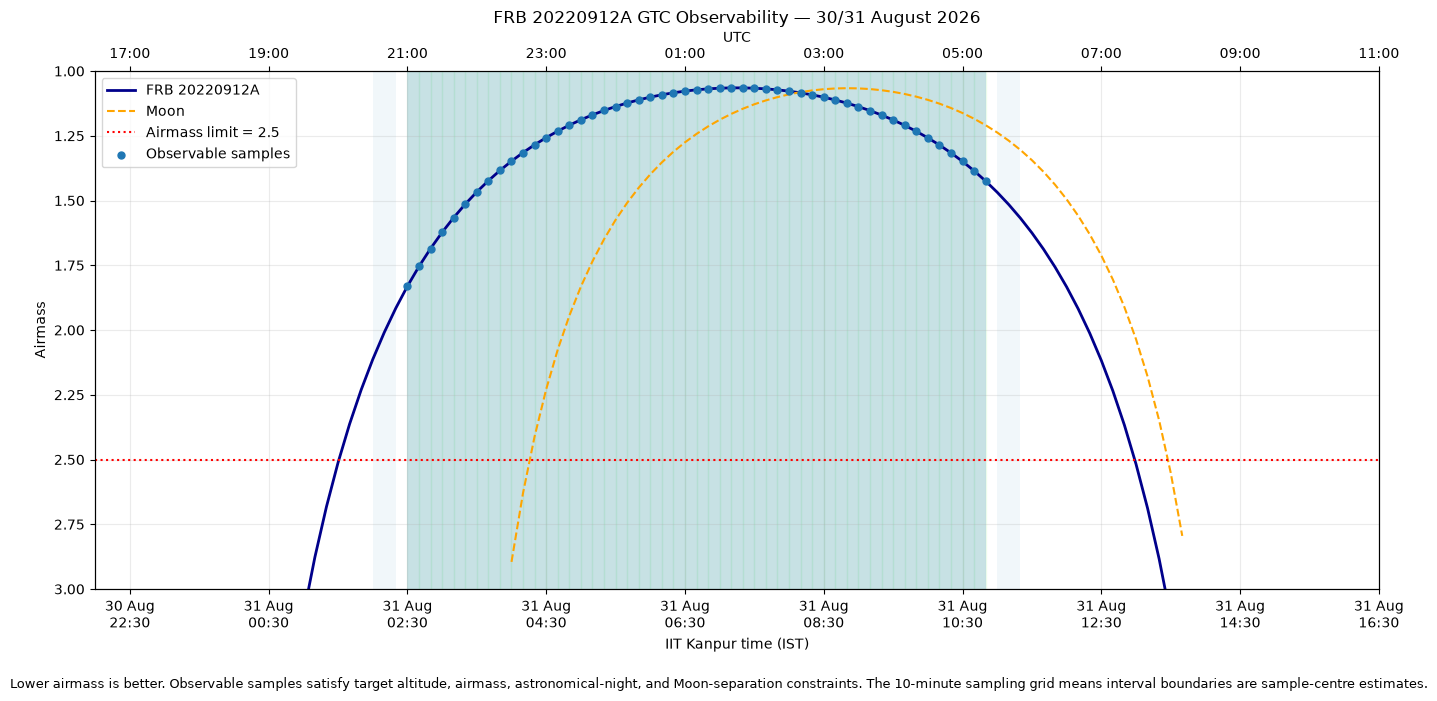


Figure saved to: assignment_outputs/frb_20220912a_gtc_airmass.png


In [93]:
# YOUR ANSWER:
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

preferred_visibility_array = visibility(
    frb_gtc_altaz.alt.to_value(u.deg),
    target_airmass,
    sun_altitude,
    moon_separation
)

def stitch_windows(times, visibility_state):

    times = Time(times)
    visibility_state = np.asarray(
        visibility_state,
        dtype=bool
    )

    if times.ndim != 1 or visibility_state.ndim != 1:
        raise ValueError("Inputs must be one-dimensional.")

    if len(times) != len(visibility_state):
        raise ValueError(
            "times and visibility_state must have equal length."
        )

    windows = []
    start = None

    for i, visible in enumerate(visibility_state):

        if visible and start is None:
            start = i

        if start is not None:
            if (not visible) or i == len(visibility_state) - 1:

                end = i if visible else i - 1

                windows.append(
                    (start, end)
                )

                start = None

    return windows


windows = stitch_windows(
    times,
    preferred_visibility_array
)


print("OBSERVING INTERVALS")


if len(windows) == 0:

    print("No observable intervals found.")

else:

    for number, (start, end) in enumerate(windows, start=1):

        interval_times = times[start:end + 1]

        duration_minutes = (
            interval_times[-1] - interval_times[0]
        ).to_value(u.min)

        best_local_index = np.nanargmin(
            target_airmass[start:end + 1]
        )

        best_index = start + best_local_index

        midpoint_index = (
            start + end
        ) // 2

        print(f"\nInterval {number}")

        print(
            "Start UTC:",
            format_utc(times[start])
        )

        print(
            "End UTC:",
            format_utc(times[end])
        )

        print(
            "Start IST:",
            format_iitk(times[start])
        )

        print(
            "End IST:",
            format_iitk(times[end])
        )

        print(
            "Sample-centre duration:",
            duration_minutes,
            "minutes"
        )

        print(
            "Best target airmass:",
            target_airmass[best_index]
        )

        print(
            "Midpoint Moon label:",
            moon_label[midpoint_index]
        )

os.makedirs(
    "assignment_outputs",
    exist_ok=True
)


moon_airmass_plot = np.asarray(
    moon_airmass,
    dtype=float
)

moon_airmass_plot[
    ~np.isfinite(moon_airmass_plot)
] = np.nan


time_datetime = times.to_datetime(
    timezone=IITK_TIMEZONE
)

utc_datetime = times.to_datetime(
    timezone=None
)


fig, ax = plt.subplots(
    figsize=(14, 7)
)

# Target airmass
ax.plot(
    time_datetime,
    target_airmass,
    color="darkblue",
    linewidth=2,
    label="FRB 20220912A"
)

# Moon airmass
ax.plot(
    time_datetime,
    moon_airmass_plot,
    linestyle="--",
    color="orange",
    linewidth=1.5,
    label="Moon"
)

# Airmass limit
ax.axhline(
    MAX_AIRMASS,
    color="red",
    linestyle=":",
    linewidth=1.5,
    label="Airmass limit = 2.5"
)

sun_altitude_values = np.asarray(
    sun_altitude,
    dtype=float
)

night = (
    sun_altitude_values <= -18
)

twilight = (
    (sun_altitude_values > -18)
    & (sun_altitude_values <= -12)
)


# Shade contiguous regions
for i in range(len(times) - 1):

    if night[i] and night[i + 1]:

        ax.axvspan(
            time_datetime[i],
            time_datetime[i + 1],
            color="lightgreen",
            alpha=0.12
        )

    elif twilight[i] and twilight[i + 1]:

        ax.axvspan(
            time_datetime[i],
            time_datetime[i + 1],
            alpha=0.06
        )

for start, end in windows:

    ax.axvspan(
        time_datetime[start],
        time_datetime[end],
        alpha=0.20
    )

visible_indices = np.where(
    preferred_visibility_array
)[0]

ax.scatter(
    time_datetime[visible_indices],
    target_airmass[visible_indices],
    s=25,
    marker="o",
    label="Observable samples",
    zorder=5
)

ax.set_ylim(3, 1)

ax.set_ylabel(
    "Airmass"
)

ax.set_xlabel(
    "IIT Kanpur time (IST)"
)

ax.set_title(
    "FRB 20220912A GTC Observability — 30/31 August 2026"
)

ax.grid(
    alpha=0.25
)

ax.xaxis.set_major_locator(
    mdates.HourLocator(interval=2)
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter(
        "%d %b\n%H:%M",
        tz=IITK_TIMEZONE
    )
)


ax_utc = ax.twiny()

ax_utc.set_xlim(
    ax.get_xlim()
)

utc_ticks = ax.get_xticks()

ax_utc.set_xticks(
    utc_ticks
)

utc_tick_datetimes = (
    mdates.num2date(
        utc_ticks,
        tz=IITK_TIMEZONE
    )
)

utc_labels = []

for dt in utc_tick_datetimes:

    utc_dt = dt.astimezone(
        __import__("datetime").timezone.utc
    )

    utc_labels.append(
        utc_dt.strftime("%H:%M")
    )

ax_utc.set_xticklabels(
    utc_labels
)

ax_utc.set_xlabel(
    "UTC"
)

ax.legend(
    loc="upper left"
)

fig.text(
    0.5,
    0.01,
    "Lower airmass is better. Observable samples satisfy "
    "target altitude, airmass, astronomical-night, and "
    "Moon-separation constraints. The 10-minute sampling "
    "grid means interval boundaries are sample-centre estimates.",
    ha="center",
    fontsize=9
)

plt.tight_layout(
    rect=[0, 0.04, 1, 1]
)

output_path = (
    "assignment_outputs/"
    "frb_20220912a_gtc_airmass.png"
)

plt.savefig(
    output_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    "\nFigure saved to:",
    output_path
)
# Write and run your code here. Add a Markdown cell below when an explanation is requested.

# Part F. All-sky observability (2 assessed marks + 2 optional bonus marks)

The previous parts established the physical ingredients needed for an observing decision. The next questions reuse those same ideas at increasing scale: first one source on one date, then a weekly all-sky GTC visibility animation over one year.

For Q19–Q20, use the geometric/airmass GTC visibility rule developed in the notebook: the source or sky position must be above the horizon, satisfy the GTC airmass limit, and be inside astronomical night. Do not include the Moon in these questions.


## Q19. Find the GTC visibility window of the repeating FRB on one date [2 marks]

Treat FRB 20220912A as a repeating source at its fixed ICRS/J2000 position. For `2026-09-01`, calculate its visibility from GTC across the full UTC day using the same HEALPix-style visibility logic: astronomical night, target altitude above the horizon, and target airmass no larger than 2.5. Report the start and end of each contiguous visibility interval in UTC and IIT Kanpur time, together with the total visible duration in hours.

This is a **single source**, not an all-sky calculation.


In [94]:
# YOUR ANSWER:

q19_start = Time(
    "2026-09-01T00:00:00",
    scale="utc"
)

q19_stop = Time(
    "2026-09-02T00:00:00",
    scale="utc"
)

q19_step = 10 * u.min

q19_times = Time(
    np.arange(
        q19_start.jd,
        q19_stop.jd + q19_step.to_value(u.day) / 2,
        q19_step.to_value(u.day)
    ),
    format="jd",
    scale="utc"
)

q19_altaz = frb_icrs.transform_to(
    AltAz(
        obstime=q19_times,
        location=gtc_location,
        pressure=0 * u.hPa
    )
)

q19_altitude = q19_altaz.alt.to_value(
    u.deg
)

q19_airmass = np.asarray(
    q19_altaz.secz,
    dtype=float
)

q19_sun = get_sun(
    q19_times
).transform_to(
    AltAz(
        obstime=q19_times,
        location=gtc_location,
        pressure=0 * u.hPa
    )
)

q19_sun_altitude = q19_sun.alt.to_value(
    u.deg
)

q19_night = (
    q19_sun_altitude <= -18.0
)

q19_altitude_ok = (
    q19_altitude > 0
)

q19_airmass_ok = (
    np.isfinite(q19_airmass)
    & (q19_airmass >= 1)
    & (q19_airmass <= 2.5)
)

q19_visible = (
    q19_night
    & q19_altitude_ok
    & q19_airmass_ok
)

q19_windows = stitch_windows(
    q19_times,
    q19_visible
)

print("\n" + "=" * 65)
print("Q19 — FRB 20220912A GTC VISIBILITY")
print("=" * 65)

print("Date: 2026-09-01")
print(
    "Total visible samples:",
    np.count_nonzero(q19_visible)
)

if len(q19_windows) == 0:

    print("\nNo visibility interval found.")

else:

    total_duration_hours = 0.0

    for number, (start, end) in enumerate(
        q19_windows,
        start=1
    ):

        duration_hours = (
            q19_times[end] - q19_times[start]
        ).to_value(u.hour)

        total_duration_hours += duration_hours

        print(f"\nInterval {number}")

        print(
            "Start UTC:",
            format_utc(q19_times[start])
        )

        print(
            "End UTC:",
            format_utc(q19_times[end])
        )

        print(
            "Start IST:",
            format_iitk(q19_times[start])
        )

        print(
            "End IST:",
            format_iitk(q19_times[end])
        )

        print(
            "Duration:",
            duration_hours,
            "hours"
        )

    print(
        "\nTotal visible duration:",
        total_duration_hours,
        "hours"
    )
# Write and run your code here. Add a Markdown cell below when an explanation is requested.


Q19 — FRB 20220912A GTC VISIBILITY
Date: 2026-09-01
Total visible samples: 52

Interval 1
Start UTC: 2026-09-01 00:00:00 UTC
End UTC: 2026-09-01 05:20:00 UTC
Start IST: 2026-09-01 05:30:00 IST
End IST: 2026-09-01 10:50:00 IST
Duration: 5.333333373069763 hours

Interval 2
Start UTC: 2026-09-01 21:00:00 UTC
End UTC: 2026-09-02 00:00:00 UTC
Start IST: 2026-09-02 02:30:00 IST
End IST: 2026-09-02 05:30:00 IST
Duration: 3.000000022351742 hours

Total visible duration: 8.333333395421505 hours


## Q20. Generate a one-year GTC visibility animation [2 bonus marks]

Use the same **all-sky GTC visibility** model over the next year, starting on **2026-08-30** and sampled every 7 days. With a weekly cadence, the final sample within the 365-day window is **2027-08-29**. For each date, compute the HEALPix visibility map using the same GTC astronomical-night, altitude, and airmass conditions developed earlier.

Save each weekly map as a PNG frame and combine the frames into a GIF. The animation should show how the observable sky from GTC changes through the year. Use a moderate HEALPix resolution so that the calculation is practical.

Briefly describe what changes across the animation and why the observable region changes with date.

In [95]:
# YOUR ANSWER:

import os
import imageio.v2 as imageio
import healpy as hp
import matplotlib.pyplot as plt


Q20_NSIDE = 16

Q20_START = Time(
    "2026-08-30T00:00:00",
    scale="utc"
)

Q20_END = Time(
    "2027-08-29T00:00:00",
    scale="utc"
)

Q20_STEP = 7 * u.day

Q20_OUTPUT_DIR = (
    "assignment_outputs/"
    "gtc_visibility_frames"
)

Q20_GIF = (
    "assignment_outputs/"
    "gtc_visibility_one_year.gif"
)

os.makedirs(
    Q20_OUTPUT_DIR,
    exist_ok=True
)


q20_jd = np.arange(
    Q20_START.jd,
    Q20_END.jd + 0.1,
    Q20_STEP.to_value(u.day)
)

q20_dates = Time(
    q20_jd,
    format="jd",
    scale="utc"
)

print(
    "Number of weekly frames:",
    len(q20_dates)
)

npix = hp.nside2npix(
    Q20_NSIDE
)

theta, phi_hp = hp.pix2ang(
    Q20_NSIDE,
    np.arange(npix)
)

# HEALPix theta = colatitude
# phi = right ascension

q20_dec = (
    90.0 - np.degrees(theta)
) * u.deg

q20_ra = (
    np.degrees(phi_hp)
) * u.deg


q20_sky = SkyCoord(
    ra=q20_ra,
    dec=q20_dec,
    frame="icrs"
)


frame_paths = []

for frame_number, date in enumerate(q20_dates):

    print(
        f"Frame {frame_number + 1}/{len(q20_dates)}:",
        date.utc.isot[:10]
    )

    # Sun altitude
    sun = get_sun(
        date
    ).transform_to(
        AltAz(
            obstime=date,
            location=gtc_location,
            pressure=0 * u.hPa
        )
    )

    sun_altitude = sun.alt.to_value(
        u.deg
    )

    astronomical_night = (
        sun_altitude <= -18.0
    )

    # Target sky altitude
    sky_altaz = q20_sky.transform_to(
        AltAz(
            obstime=date,
            location=gtc_location,
            pressure=0 * u.hPa
        )
    )

    altitude = sky_altaz.alt.to_value(
        u.deg
    )

    airmass = np.asarray(
        sky_altaz.secz,
        dtype=float
    )

    # GTC visibility rule
    visible = (
        (altitude > 0)
        & np.isfinite(airmass)
        & (airmass >= 1)
        & (airmass <= 2.5)
        & astronomical_night
    )

    # HEALPix map: 1 = visible, 0 = not visible
    visibility_map = visible.astype(
        float
    )

    fig = plt.figure(
        figsize=(10, 6)
    )

    hp.mollview(
        visibility_map,
        fig=fig.number,
        title=(
            "GTC All-Sky Visibility\n"
            f"{date.utc.isot[:10]}"
        ),
        coord="C",
        min=0,
        max=1,
        cbar=True,
        unit="Visible"
    )

    hp.graticule()

    # Save frame
    frame_path = os.path.join(
        Q20_OUTPUT_DIR,
        f"gtc_visibility_{frame_number:03d}.png"
    )

    plt.savefig(
        frame_path,
        dpi=120,
        bbox_inches="tight"
    )

    plt.close(fig)

    frame_paths.append(
        frame_path
    )



images = []

for path in frame_paths:

    images.append(
        imageio.imread(path)
    )

imageio.mimsave(
    Q20_GIF,
    images,
    duration=0.35,
    loop=0
)

print("\n" + "=" * 65)
print("Q20 COMPLETE")
print("=" * 65)

print(
    "Frames created:",
    len(frame_paths)
)

print(
    "Frame directory:",
    Q20_OUTPUT_DIR
)

print(
    "GIF saved to:",
    Q20_GIF
)
# Write and run your code here. Add a Markdown cell below when an explanation is requested.

Number of weekly frames: 53
Frame 1/53: 2026-08-30


c:\Users\ambat\miniconda3\envs\astronomy\Lib\site-packages\healpy\visufunc.py:225: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  f = pylab.figure(fig, figsize=(8.5, 5.4))


Frame 2/53: 2026-09-06
Frame 3/53: 2026-09-13
Frame 4/53: 2026-09-20
Frame 5/53: 2026-09-27
Frame 6/53: 2026-10-04
Frame 7/53: 2026-10-11
Frame 8/53: 2026-10-18
Frame 9/53: 2026-10-25
Frame 10/53: 2026-11-01
Frame 11/53: 2026-11-08
Frame 12/53: 2026-11-15
Frame 13/53: 2026-11-22
Frame 14/53: 2026-11-29
Frame 15/53: 2026-12-06
Frame 16/53: 2026-12-13
Frame 17/53: 2026-12-20
Frame 18/53: 2026-12-27
Frame 19/53: 2027-01-03
Frame 20/53: 2027-01-10
Frame 21/53: 2027-01-17
Frame 22/53: 2027-01-24
Frame 23/53: 2027-01-31
Frame 24/53: 2027-02-07
Frame 25/53: 2027-02-14
Frame 26/53: 2027-02-21
Frame 27/53: 2027-02-28
Frame 28/53: 2027-03-07
Frame 29/53: 2027-03-14
Frame 30/53: 2027-03-21
Frame 31/53: 2027-03-28
Frame 32/53: 2027-04-04
Frame 33/53: 2027-04-11
Frame 34/53: 2027-04-18
Frame 35/53: 2027-04-25
Frame 36/53: 2027-05-02
Frame 37/53: 2027-05-09
Frame 38/53: 2027-05-16
Frame 39/53: 2027-05-23
Frame 40/53: 2027-05-30
Frame 41/53: 2027-06-06
Frame 42/53: 2027-06-13
Frame 43/53: 2027-06-20



Q20 COMPLETE
Frames created: 53
Frame directory: assignment_outputs/gtc_visibility_frames
GIF saved to: assignment_outputs/gtc_visibility_one_year.gif




The animation shows how the observable sky from the GTC changes throughout the year. For each weekly sample, the sky was divided into HEALPix pixels and each pixel was tested using the GTC visibility conditions: the position must be above the horizon, have an airmass between 1 and 2.5, and lie within astronomical night, defined by a Sun altitude of at most −18°.

The observable region changes with date because the apparent position of the Sun changes relative to the fixed celestial coordinate grid. Consequently, different parts of the sky satisfy the astronomical-night condition at different times of the year. The GTC altitude and airmass limits further restrict the observable region to directions that are sufficiently high above the horizon.

The animation uses a weekly cadence from 2026-08-30 to 2027-08-29 and a HEALPix resolution of NSIDE = 16. Therefore, changes occurring between the weekly samples are not represented continuously.


## Submission checklist

- Restart the kernel and run every cell from top to bottom.
- Keep units attached during physical calculations.
- Use UTC internally; show IIT Kanpur time whenever reporting a civil clock time.
- Label Local Sidereal Time as LST, never IST.
- Keep the exact `visibility(altitude, airmass, sun_altitude, moon_separation)` interface.
- Confirm `assignment_outputs/frb_20220912a_gtc_airmass.png` exists and is non-empty.
- Confirm the Q20 one-year GTC GIF and its generated weekly frame PNGs are present.

## Compact glossary

- **Astropy quantity:** a numerical value stored together with a physical unit.
- **UTC:** the standard time scale used to identify an instant worldwide.
- **IST:** Indian Standard Time, the IIT Kanpur civil clock, UTC+05:30.
- **JD/MJD:** continuous astronomical day counts; MJD is JD minus 2,400,000.5.
- **ICRS:** a modern standard equatorial frame expressed with RA and Dec.
- **Galactic coordinates:** longitude $l$ and latitude $b$ referred to the Milky Way.
- **Ecliptic coordinates:** longitude $\lambda$ and latitude $\beta$ referred to Earth's orbital plane; longitude begins at the vernal equinox.
- **Angular separation:** the shortest great-circle angle between two directions on the celestial sphere.
- **Mollweide projection:** an equal-area elliptical map of the full celestial sphere; Matplotlib expects longitude and latitude in radians.
- **LST:** Local Sidereal Time, an astronomical angle determined by time and longitude.
- **Hour angle:** $H=\mathrm{LST}-\alpha$; zero at meridian transit.
- **Transit:** passage across the local meridian; usually the highest geometric altitude.
- **AltAz:** a horizon frame determined by observer location and time.
- **Zenith distance:** angular distance from the zenith, $z=90^\circ-h$.
- **Airmass:** approximate atmospheric path length relative to the zenith.
- **Astronomical darkness:** Sun altitude at or below $-18^\circ$ in this assignment.
- **Observable interval:** consecutive samples satisfying every printed condition.

- **HEALPix:** a hierarchical equal-area pixelization of the celestial sphere; each pixel can store an astronomical quantity such as visibility time.
- **Visibility time:** the amount of time a source satisfies the observing constraints during a specified interval.
- **Repeating FRB:** an FRB that can produce bursts on multiple occasions, so a future observing schedule can be planned for its fixed sky position.
